# Skysat

In [1]:
import rioxarray as rxr
import json

In [2]:
base_path = 'Nairobi_2024_2019_skysatcollect_analytic_sr_udm2'
with open(f'{base_path}/manifest.json') as f:
    d = json.load(f)

files = [f['path'] for f in d['files'] if '_SR_' in f['path']]
files

['SkySatCollect/20240506_112857_ssc8_u0002_analytic_SR_clip_file_format.tif',
 'SkySatCollect/20190416_102911_ssc9_u0001_analytic_SR_clip_file_format.tif',
 'SkySatCollect/20190416_102955_ssc9_u0001_analytic_SR_clip_file_format.tif']

In [3]:
for f in files:
    ds = rxr.open_rasterio(f'{base_path}/{f}')
    ds = ds.where(ds!=65535).where(ds!=0)
    ndwi=(ds.isel(band=1)-ds.isel(band=3))/(ds.isel(band=1)+ds.isel(band=3))
    ndwi.rio.to_raster(f'skysat_ndwi_{f.split('/')[-1][:15]}.tif')

In [4]:
#𝑁𝐼𝑆𝐼=(𝐵𝑏𝑙𝑢𝑒+𝐵𝑔𝑟𝑒𝑒𝑛+𝐵𝑟𝑒𝑑)−𝐵𝑁𝐼𝑅(𝐵𝑏𝑙𝑢𝑒+𝐵𝑔𝑟𝑒𝑒𝑛+𝐵𝑟𝑒𝑑)+𝐵𝑁𝐼𝑅

for f in files:
    ds = rxr.open_rasterio(f'{base_path}/{f}')
    ds = ds.where(ds!=65535).where(ds!=0)
    nisi=((ds.isel(band=0)+ds.isel(band=1)+ds.isel(band=2))/3.-ds.isel(band=3))/((ds.isel(band=0)+ds.isel(band=1)+ds.isel(band=2))/3.+ds.isel(band=3))
    nisi.rio.to_raster(f'skysat_nisi_{f.split('/')[-1][:15]}.tif')

In [8]:
ndwi = rxr.open_rasterio('skysat_ndwi_20240506_112857.tif').squeeze()
nisi = rxr.open_rasterio('skysat_nisi_20240506_112857.tif').squeeze()

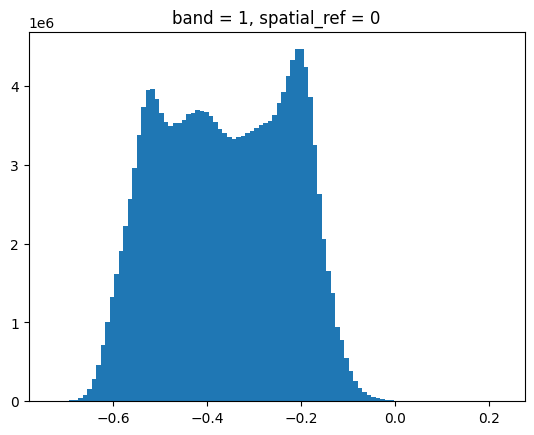

In [9]:
ndwi.plot.hist(bins=100);

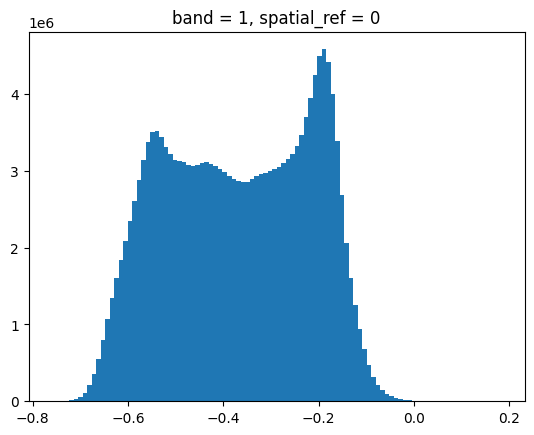

In [7]:
nisi.plot.hist(bins=100);

In [10]:
nisi_2024 = rxr.open_rasterio('skysat_nisi_20240506_112857.tif').squeeze()
nisi_2019 = rxr.open_rasterio('skysat_nisi_20190416_102955.tif').squeeze()

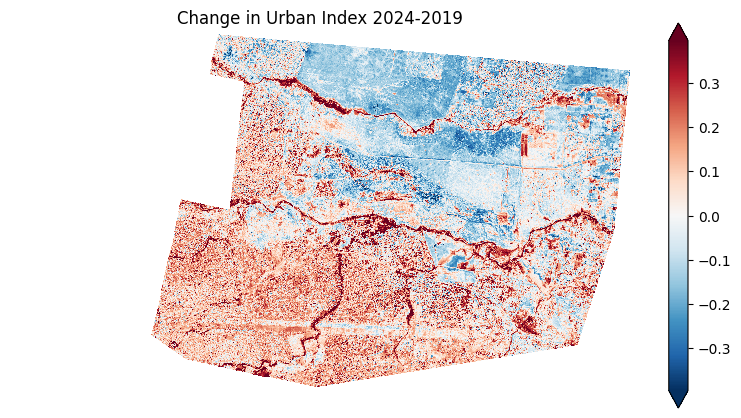

In [16]:
from matplotlib import pyplot as plt 
ax = (nisi_2024-nisi_2019).plot.imshow(figsize=(10,5), robust=True);
# Remove axes
ax.axes.set_aspect('equal') 
ax.axes.set_axis_off();
ax.axes.set_title('Change in Urban Index 2024-2019');
plt.savefig('nisi_diff.png', dpi=300, bbox_inches='tight')